# Fotogrametría: Reconstrucción 3D de objetos

In [ ]:
import os

import cv2 as cv

import matplotlib.pyplot as plt
import numpy as np
import plotly.graph_objects as go
from scipy.spatial import cKDTree
import pyvista as pv
import rembg

En esta etapa inicial, el objetivo es preparar las imágenes crudas para maximizar la calidad de la reconstrucción 3D. El flujo de trabajo consiste en:

1.  **Carga de Imágenes**: Lectura del dataset original.
2.  **Corrección Gamma**: Aplicamos una expansión de señal (gamma > 1.0) para realzar detalles en zonas de sombra sin saturar las luces. Esto ayuda a que el algoritmo de segmentación distinga mejor el objeto del fondo.
3.  **Eliminación de Fondo (Segmentation)**: Utilizamos `rembg` (basado en U2Net) para generar una máscara de transparencia (canal Alpha). Eliminar el fondo reduce el ruido y evita que se generen puntos 3D erróneos fuera del objeto de interés.
4.  **Guardado**: Las imágenes procesadas se guardan en formato PNG (con transparencia) para ser usadas en las siguientes etapas.

Este preprocesamiento es crítico para asegurar que los algoritmos de detección de características (SIFT) se concentren únicamente en la geometría del objeto.

## 1. Preprocesado

In [138]:
SAMPLES_DIR = 'Samples'
SAMPLE_BASE_PATH = os.path.join(SAMPLES_DIR, '09_Samples')
SAMPLE_STATE_00  = os.path.join(SAMPLE_BASE_PATH, '00_state')
IMAGES = []

print("Cargando imágenes...")
# Procesamos todas las imágenes encontradas en el directorio
for i in range(1, len(os.listdir(SAMPLE_STATE_00)) + 1):
    print(f"|-> Procesando imagen {i:02d} de {len(os.listdir(SAMPLE_STATE_00))}", end='\r')
    file_path = os.path.join(SAMPLE_STATE_00, f"{i:02d}_model.jpeg")

    IMAGES.append(cv.imread(file_path, cv.IMREAD_COLOR_RGB))
print("Imágenes cargadas correctamente.")

Cargando imágenes...
Imágenes cargadas correctamente.
Imágenes cargadas correctamente.


## 1.1 Funciones de Preprocesado

Para automatizar el proceso, definimos dos funciones clave:

*   `apply_gamma(img, g)`: Aplica una transformación de potencia a los píxeles.
    *   Si $g > 1$, la imagen se oscurece, aumentando el contraste en las zonas medias.
    *   Si $g < 1$, la imagen se aclara.
    *   En nuestro caso, buscamos un valor que resalte los bordes del objeto frente al fondo.
*   `remove_background(img_rgba, session, gamma)`: Orquesta el proceso completo para una imagen:
    1.  Separa los canales RGB.
    2.  Aplica la corrección gamma temporalmente para mejorar la detección.
    3.  Pasa la imagen mejorada a `rembg` para obtener la máscara.
    4.  Aplica la máscara a la imagen **original** (sin gamma alterado) para preservar los colores reales de la textura.

In [139]:
def apply_gamma(img, gamma):
    img_f = img.astype(np.float32) / 255.0
    img_f = np.clip(np.power(img_f, gamma), 0.0, 1.0)
    return (img_f * 255).astype(np.uint8)

def remove_background(img, session, gamma=1.0):
    img_copy = img.copy()

    img_enhanced = apply_gamma(img_copy, gamma)
    mask = rembg.remove(img_enhanced, session=session, only_mask=True)
    
    rgba = np.dstack((img, mask))
    rgba[mask == 0] = 0
    return rgba

## 1.2 Experimentación

### 1.2.1: Benchmark de Gamma

No existe un valor de gamma universal; depende de la iluminación de la escena. Realizamos un test visual con tres valores:
*   **Gamma 1.0**: Imagen original.
*   **Gamma 1.5**: Contraste medio.
*   **Gamma 2.0**: Contraste alto (sombras más marcadas).

**Objetivo**: Buscamos el valor que produzca la máscara más limpia (bordes suaves, sin "mordiscos" al objeto y sin restos de fondo). Visualizamos los resultados lado a lado.

In [140]:
def benchmark_gamma(images, gammas): 
    default_rembg_session = rembg.new_session("u2net") 

    selected_images = images[0::11]
    rows, cols = len(gammas) + 1, len(selected_images)
    fig, axes = plt.subplots(rows, cols, figsize=(3 * cols, 4 * rows)) 
    fig.suptitle("Benchmark diferentes valores de gamma, 1 imagen cada 11", fontsize=20)
    
    for i, img_rgb in enumerate(selected_images): 
        axes[0, i].imshow(img_rgb) 
        axes[0, i].axis('off') 
        if i == cols // 2: 
            axes[0, i].set_title("Original", fontsize=16) 

        for j, g in enumerate(gammas): 
            img_no_bg = remove_background(img_rgb, default_rembg_session, gamma=g) 
             
            axes[j+1, i].imshow(img_no_bg) 
            axes[j+1, i].axis('off') 
            if i == cols // 2: 
                axes[j+1, i].set_title(f"Gamma {g}", fontsize=16) 
    
    plt.tight_layout()
    plt.show()

In [141]:
GAMMAS = [1.0, 1.25, 1.5] 
#benchmark_gamma(IMAGES, GAMMAS)

Como se puede observar, el mejor valor de gamma para este conjunto de imágenes es 1.5, ya que proporciona un buen equilibrio entre la eliminación del fondo y la preservación de los detalles del objeto.

In [142]:
GAMMA = 1.25

### 1.2.1 Selección de Modelo de Segmentación

La librería `rembg` permite utilizar diferentes modelos de redes neuronales para la segmentación (ej. `u2net`, `u2netp`, `isnet-general-use`, `sam`).

Aunque el modelo por defecto (`u2net`) ofrece un excelente equilibrio entre calidad y rendimiento para objetos generales, en casos donde el objeto tiene detalles muy finos (como cabello o mallas) o un contraste muy bajo con el fondo, sería recomendable realizar un segundo benchmark comparando estos modelos.

Para este proyecto, tras la evaluación visual del benchmark de gamma, determinamos que **`u2net` con Gamma=2.0** proporciona resultados satisfactorios, por lo que procedemos con esta configuración.

In [143]:
def benchmark_rembg_models(images, gamma):
    model_names = [
        "u2net", #"u2netp", "u2net_human_seg", "u2net_cloth_seg", 
        #"silueta", "isnet-general-use", "isnet-anime"
    ]
    print(f"Iniciando benchmark de modelos con Gamma={gamma}...")
    
    selected_images = images[0::11]
    # Pre-cargamos sesiones para evitar recrearlas en el bucle interno
    sessions = {name: rembg.new_session(name) for name in model_names}
    
    rows = len(model_names) + 1
    cols = len(selected_images)

    fig, axes = plt.subplots(rows, cols, figsize=(3 * cols, 4 * rows)) 
    fig.suptitle("Benchmark diferentes modelos de IA de gamma, 1 imagen cada 11", fontsize=20)

    for i, img in enumerate(selected_images):
        # 1. Original
        axes[0, i].imshow(img)
        axes[0, i].axis('off')
        if i == len(selected_images) // 2:
            axes[0, i].set_title("Original", fontsize=16)

        # 2. Modelos
        for j, name in enumerate(model_names):
            # Usamos la sesión pre-cargada y nuestra función remove_background
            res = remove_background(img, sessions[name], gamma=gamma)
            
            axes[j+1, i].imshow(res)
            axes[j+1, i].axis('off')
            if i == len(selected_images) // 2:
                axes[j+1, i].set_title(name, fontsize=16)

    print("\nBenchmark finalizado.")
    plt.tight_layout()
    plt.show()

In [144]:
#benchmark_rembg_models(IMAGES, GAMMA)

In [145]:
REMBG_SESSION = rembg.new_session("u2net")

Como vemos en los resultados, el modelo "u2net" con un ajuste de gamma de 1.5 ofrece un equilibrio óptimo entre la precisión del recorte y la preservación de detalles importantes en las imágenes de nuestro objeto de interés.

## 1.3 Ejecución del Pipeline de Preprocesado

Con los parámetros definidos (**Gamma = 1.5**), ejecutamos el procesamiento por lotes para todo el dataset.

El script iterará sobre todas las imágenes cargadas:
1.  Aplicará la eliminación de fondo con la configuración óptima.
2.  Convertirá el resultado al espacio de color BGRA (requerido por OpenCV para guardar).
3.  Guardará los archivos `.png` resultantes en el directorio de salida (`01_state` o similar), listos para la extracción de características.

In [146]:
IMAGES_BGLESS = []
SAMPLE_STATE_01  = os.path.join(SAMPLE_BASE_PATH, '01_state')

print("Iniciando procesamiento...")
for i, img_rgba in enumerate(IMAGES):
    final_img = remove_background(img_rgba, REMBG_SESSION, gamma=GAMMA)
    IMAGES_BGLESS.append(final_img)
    
    filename = f"{i+1:02d}_model.png"
    out_path = os.path.join(SAMPLE_STATE_01, filename)
    cv.imwrite(out_path, final_img)
    # Usamos end='\r' para sobrescribir la línea y evitar imprimir una lista larga
    print(f"|-> Procesada imagen: {filename}", end='\r')

print("") # Salto de línea final
print('Procesamiento completado.')

Iniciando procesamiento...
|-> Procesada imagen: 55_model.png
Procesamiento completado.
|-> Procesada imagen: 55_model.png
Procesamiento completado.


# 2. Extracción y detección de características

## 2.1 Algoritmo SIFT (Scale-Invariant Feature Transform)

Para la reconstrucción 3D, es fundamental encontrar puntos correspondientes ("matches") entre pares de imágenes consecutivas. Para ello, utilizamos el algoritmo **SIFT**, un estándar en visión por computador valorado por su gran robustez.

**¿Por qué usamos SIFT?**
A diferencia de otros detectores de esquinas simples, SIFT es capaz de detectar y describir características locales ("keypoints") que son invariantes a:
*   **Escala**: Reconoce el mismo detalle aunque el objeto esté más cerca o más lejos en la foto.
*   **Rotación**: Funciona correctamente aunque la cámara o el objeto hayan girado.
*   **Iluminación**: Es parcialmente invariante a cambios de luz y ruido.

**El flujo de trabajo implementado es:**

1.  **Detección de Keypoints**: Identificamos puntos de interés distintivos en ambas imágenes.
2.  **Cálculo de Descriptores**: Para cada punto, SIFT genera una "huella digital" numérica (vector de 128 valores) que describe la textura y gradientes a su alrededor.
3.  **Matching (Emparejamiento)**: Comparamos los descriptores de la *Imagen A* con los de la *Imagen B*. Utilizamos `BFMatcher` (Brute Force) con `knnMatch` ($k=2$) para encontrar los **dos** mejores candidatos para cada punto.
4.  **Filtrado (Lowe's Ratio Test)**: Para descartar falsos positivos, aplicamos la "Prueba de Razón de Lowe". Solo aceptamos un emparejamiento si la distancia al *mejor* candidato es significativamente menor (por ejemplo, $< 0.7$) que la distancia al *segundo mejor*. Esto elimina ambigüedades y asegura que el match es único y confiable.

In [ ]:
def feature_and_matching(im1, im2):
    """
    Detecta características SIFT y realiza emparejamiento rápido con FLANN.
    
    Args:
        im1, im2: Imágenes de entrada (en color o gris).
        
    Returns:
        pts1, pts2: Arrays numpy con las coordenadas de los puntos coincidentes.
        kp1, kp2: Keypoints originales.
        good_matches: Lista de objetos DMatch filtrados.
    """

    # 2. Detección SIFT
    sift = cv.SIFT_create(contrastThreshold=0.02, edgeThreshold=10)
    kp1, des1 = sift.detectAndCompute(im1, None)
    kp2, des2 = sift.detectAndCompute(im2, None)

    
    # k=2 para poder aplicar el Ratio Test luego
    bf = cv.BFMatcher()
    matches = bf.knnMatch(des1, des2, k=2)

    # 4. Filtrado con Lowe's Ratio Test
    # Esto elimina la necesidad del "Cross Check" manual y es mucho más rápido.
    # Se queda solo con matches donde la mejor coincidencia es mucho mejor que la segunda.
    good_matches = []
    ratio_threshold = 0.75
    
    for m, n in matches:
        if m.distance < ratio_threshold * n.distance:
            good_matches.append(m)

    # 5. Formateo de salida
    # Convertimos directamente a array numpy de float32 para usar en homografías
    pts1 = np.float32([kp1[m.queryIdx].pt for m in good_matches]).reshape(-1, 1, 2)
    pts2 = np.float32([kp2[m.trainIdx].pt for m in good_matches]).reshape(-1, 1, 2)

    return pts1, pts2, kp1, kp2, good_matches

## 2.2 Ejecución y Visualización del Matching

A continuación, probamos la función con dos imágenes consecutivas del dataset procesado. Visualizaremos las líneas que conectan los puntos clave encontrados en ambas imágenes para verificar visualmente la calidad de los emparejamientos. Si las líneas son paralelas y coherentes, el matching es correcto; si hay muchas líneas cruzadas caóticas, el filtrado necesita ajuste.

In [148]:
def visualize_matches(images):
    # Esto mostrará el matching entre la imagen i y i+1, para i = 0, 11, 22...
    pairs = [(i, i+1) for i in range(0, len(images), 11)]
    cols, rows = 3, 2
    
    fig, axes = plt.subplots(rows, cols, figsize=(16, 5 * rows))
    fig.suptitle("Visualización de Matches entre pares de imágenes (muestreo cada 11)", fontsize=20)
    
    axes = axes.flatten()
    for idx, (idx1, idx2) in enumerate(pairs):
        img1, img2 = images[idx1], images[idx2]
        
        # Ejecutamos la función de matching
        pts1, pts2, kp1, kp2, matches = feature_and_matching(img1, img2)
        
        # Dibujamos los matches
        res = cv.drawMatches(img1, kp1, img2, kp2, matches, None, flags=2)
        
        axes[idx].imshow(res)
        axes[idx].set_title(f"Match: {idx1+1:02d} -> {idx2+1:02d} ({len(matches)} matches)")
        axes[idx].axis('off')

    axes[5].axis('off')

    plt.tight_layout()
    plt.show()

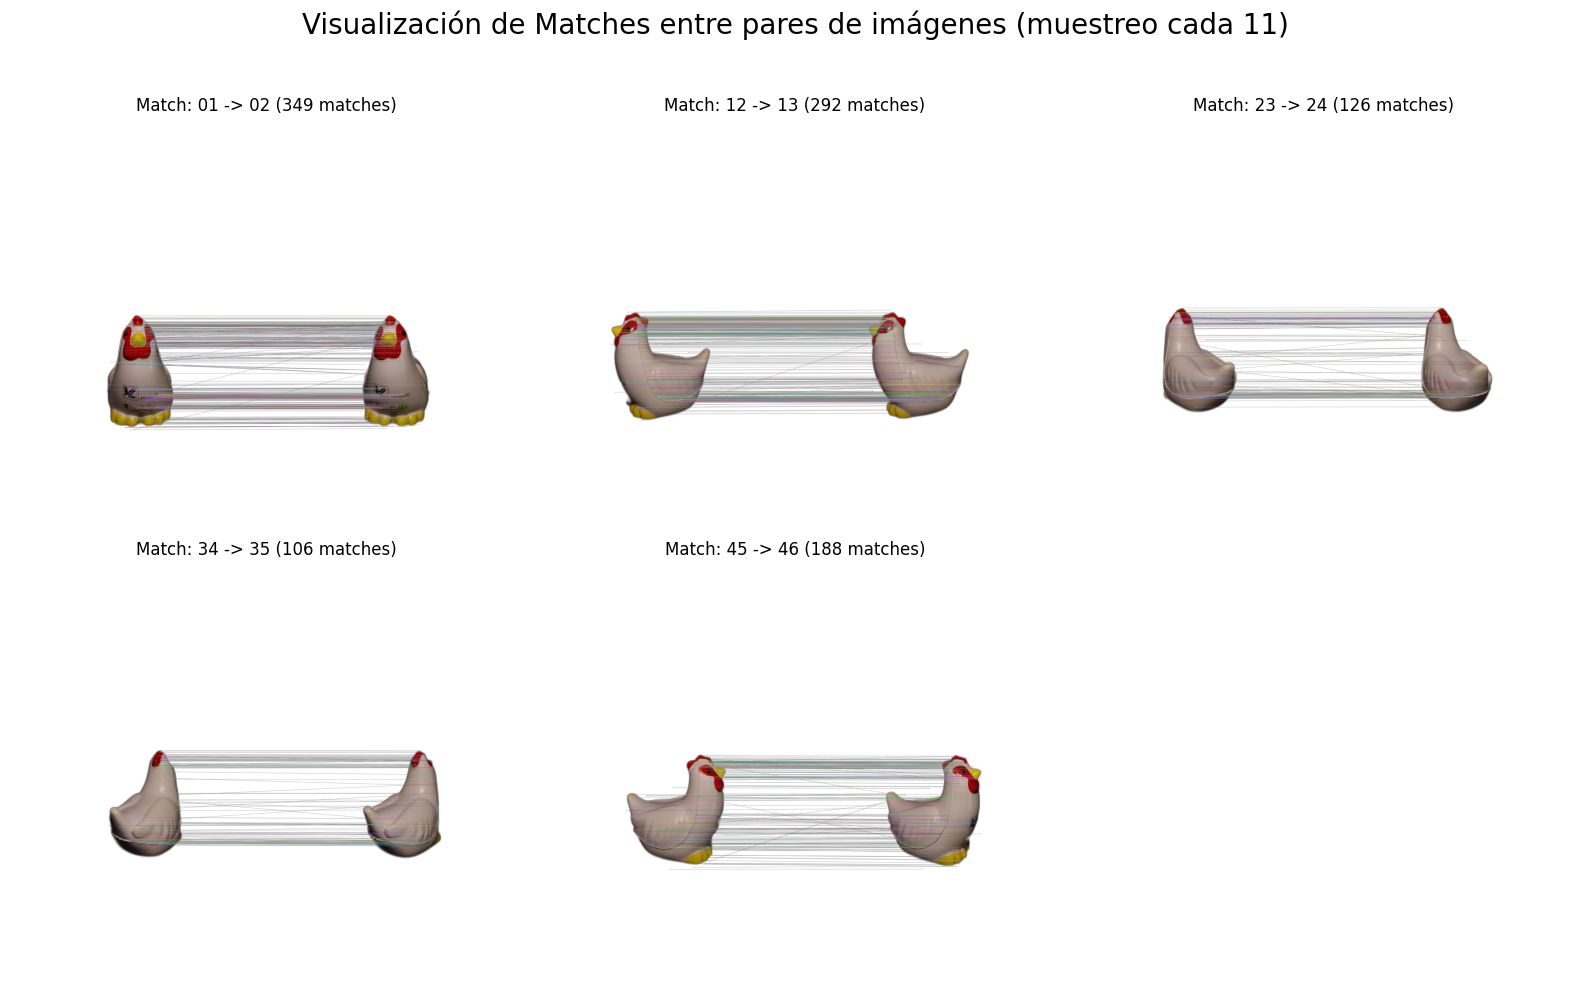

In [149]:
visualize_matches(IMAGES_BGLESS)

## Sfm: Structure from Motion

Buscamos la matriz fundamental utilizando RANSAC y validamos de la Geometría Epipolar para ver si el emparejamiento hecho anteriormente tienen verdaderamente relación geometrica

Funcion donde se tiangula las posiciones de los puntos de 2 imagenes para calcular las posiciones 3D de dichas imagenes.

In [150]:
def Sfm_circular(im1, im2, K, idx1, idx2, n_imgs, rad, direction=1):
    """
    Realiza la reconstrucción 3D asumiendo una trayectoria circular perfecta (Turntable).
    Calcula las poses absolutas de las cámaras basándose en sus índices.
    
    Args:
        im1, im2: Imágenes.
        K: Matriz intrínseca.
        idx1, idx2: Índices de las imágenes en la secuencia (0..N-1).
        n_imgs: Número total de imágenes.
        rad: Radio de la órbita (distancia de la cámara al centro del objeto).
        direction: 1 o -1. Invierte el sentido de la rotación.
    """
    
    # 1. Obtener Puntos Emparejados
    pts1, pts2, kp1, kp2, good_matches = feature_and_matching(im1, im2)
    
    # --- FILTRADO DE OUTLIERS (NUEVO) ---
    # Usamos RANSAC para encontrar la Matriz Fundamental y descartar matches erróneos
    # que no cumplen la geometría epipolar, antes de forzar la triangulación.
    # threshold=1.0 píxel de error máximo para considerar inlier
    pts1 = np.ascontiguousarray(pts1)
    pts2 = np.ascontiguousarray(pts2)
    F, mask = cv.findFundamentalMat(pts1, pts2, cv.FM_RANSAC, 1.0, 0.99)
        
    # Aplicamos la máscara para quedarnos solo con los inliers
    mask = mask.ravel() == 1
    pts1 = pts1[mask]
    pts2 = pts2[mask]

    # Aseguramos que los puntos tengan forma (N, 2) para triangulatePoints
    pts1 = pts1.reshape(-1, 2)
    pts2 = pts2.reshape(-1, 2)

    # 2. Calcular Poses Absolutas
    def get_pose(idx, N, R_dist, rot_dir):
        # Ángulo de rotación
        theta = rot_dir * idx * (2 * np.pi / N)
        
        # Rotación alrededor del eje Y
        c, s = np.cos(theta), np.sin(theta)
        R = np.array([
            [c, 0, s],
            [0, 1, 0],
            [-s, 0, c]
        ])
        
        # Traslación: Objeto centrado en (0,0,R_dist) frente a la cámara
        t = np.array([[0], [0], [R_dist]])
        
        return R, t

    R1, t1 = get_pose(idx1, n_imgs, rad, direction)
    R2, t2 = get_pose(idx2, n_imgs, rad, direction)

    # Matrices de Proyección
    P1 = K @ np.hstack((R1, t1))
    P2 = K @ np.hstack((R2, t2))
    
    # 3. Triangulación 3D
    pts4d = cv.triangulatePoints(P1, P2, pts1.T, pts2.T)
    
    # Normalización homogénea
    # Evitar división por cero
    w_coord = pts4d[3]
    w_coord[np.abs(w_coord) < 1e-5] = 1e-5
    
    pts3d = pts4d[:3] / w_coord
    
    # CORRECCIÓN DE EJES
    pts3d[2] *= -1

    return pts3d.T.copy()

In [151]:
P_LOW, P_HIGH = 1, 99  # Percentil inferior y superior para filtrado

h, w = IMAGES_BGLESS[0].shape[:2]
# Matriz K calibrada (proporcionada)
K = np.array([
    [2.69889306e+03, 0.00000000e+00, 1.49789941e+03],
    [0.00000000e+00, 2.76369335e+03, 2.04250158e+03],
    [0.00000000e+00, 0.00000000e+00, 1.00000000e+00]
])
dist_coeffs = np.array([0.15055201, -0.79565235, 0.00639867, -0.00277334, 1.94243501])

print("Aplicando corrección de distorsión a las imágenes...")
h, w = IMAGES_BGLESS[0].shape[:2]
    
# Ajustamos K para tener la deformación "estiramiento" de la imagen
K, roi = cv.getOptimalNewCameraMatrix(K, dist_coeffs, (w,h), alpha=1, newImgSize=(w,h))
    
IMAGES_UNDISTORTED = []
for img in IMAGES_BGLESS:
    dst = cv.undistort(img, K, dist_coeffs, None, K)
    IMAGES_UNDISTORTED.append(dst)
    
IMAGES_BGLESS = IMAGES_UNDISTORTED
print("Imágenes corregidas y Matriz K actualizada.")

Aplicando corrección de distorsión a las imágenes...
Imágenes corregidas y Matriz K actualizada.
Imágenes corregidas y Matriz K actualizada.


In [152]:
def clean_pcd_statistical(points, nb_neighbors=20, std_ratio=2.0):
    # 20 distancias mas cercanas ordenadas
    d, _ = cKDTree(points).query(points, k=nb_neighbors + 1)
    
    # 'mu' es la media de distancias locales
    mu = np.mean(d[:, 1:], axis=1)
    
    # Filtro: mantiene puntos donde la distancia media local es menor al umbral
    return points[mu < np.mean(mu) + std_ratio * np.std(mu)]

def procesar_reconstruccion_sfm(images, K, p_low=10, p_high=90):
    print(f"--- INICIO DE RECONSTRUCCIÓN SFM (CIRCULAR) ---")
    
    puntos_3d = np.zeros((0, 3))
    n_imgs = len(images)
    
    # Radio estimado (distancia al objeto). DIRECCIÓN DE ROTACIÓN:-1: Horario (o cámara antihoraria)
    RADIO = 2.0
    DIRECTION = -1

    for i in range(n_imgs):
        idx1, idx2 = i, (i + 1) % n_imgs
        img1, img2 = images[idx1], images[idx2]

        # Usamos la nueva función con poses absolutas y dirección
        puntos = Sfm_circular(img1, img2, K, idx1, idx2, n_imgs, rad=RADIO, direction=DIRECTION)
        puntos_3d = np.vstack((puntos_3d, puntos))
            
        print(f"|-> Procesado par {idx1}-{idx2}: +{len(puntos)} puntos.", end='\r')
    
    print(f"\nTotal puntos generados (bruto): {len(puntos_3d)}")

    print(f"--- FILTRADO DE PUNTOS ---")

    mascara_validos = np.isfinite(puntos_3d).any(axis=1)
    puntos_limpios = puntos_3d[mascara_validos]
    print(f"Puntos tras eliminar Inf/NaN: {len(puntos_limpios)}")

    # 1. Filtrado Estadístico (SOR) - NUEVO
    print("Aplicando Statistical Outlier Removal (SOR)...")
    puntos_sor = clean_pcd_statistical(puntos_limpios, nb_neighbors=50, std_ratio=1.0)
    print(f"Puntos tras SOR: {len(puntos_sor)} (Eliminados: {len(puntos_limpios) - len(puntos_sor)})")


    # 2. Filtrado de Caja (Percentiles)
    # Elimina puntos muy lejanos que hayan sobrevivido al SOR
    min_x, max_x = np.percentile(puntos_sor[:, 0], [p_low, p_high])
    min_y, max_y = np.percentile(puntos_sor[:, 1], [p_low, p_high])
    min_z, max_z = np.percentile(puntos_sor[:, 2], [p_low, p_high])

    filtro_percentil = (
        (puntos_sor[:, 0] > min_x) & (puntos_sor[:, 0] < max_x) &
        (puntos_sor[:, 1] > min_y) & (puntos_sor[:, 1] < max_y) &
        (puntos_sor[:, 2] > min_z) & (puntos_sor[:, 2] < max_z) 
    )
    puntos_finales = puntos_sor[filtro_percentil]
    print(f"Puntos tras FIltrado de caja: {len(puntos_finales)} (Eliminados: {len(puntos_sor) - len(puntos_finales)})")
    
    return puntos_finales

In [153]:
# 1. Ejecutar el procesamiento
puntos_finales = procesar_reconstruccion_sfm(IMAGES, K, p_low=P_LOW, p_high=P_HIGH)

# 2. Visualización
fig = go.Figure(data=[go.Scatter3d(
    x=puntos_finales[:,0],
    y=puntos_finales[:,1],
    z=puntos_finales[:,2],
    mode='markers',
    marker=dict(
        size=3,
        color=puntos_finales[:,2], # Colorear por profundidad (Z)
        colorscale='Hot',
        opacity=0.8
    )
)])

fig.update_layout(
    title=f"Nube de Puntos 3D ({len(puntos_finales)} puntos)",
    scene=dict(
        xaxis_title='X',
        yaxis_title='Y',
        zaxis_title='Z'
    ),
    margin=dict(l=0, r=0, b=0, t=30)
)

fig.show()
print(puntos_finales)

--- INICIO DE RECONSTRUCCIÓN SFM (CIRCULAR) ---
|-> Procesado par 54-0: +121 puntos..
Total puntos generados (bruto): 6017
--- FILTRADO DE PUNTOS ---
Puntos tras eliminar Inf/NaN: 6017
Aplicando Statistical Outlier Removal (SOR)...
Puntos tras SOR: 5849 (Eliminados: 168)
Puntos tras FIltrado de caja: 5495 (Eliminados: 354)
|-> Procesado par 54-0: +121 puntos.
Total puntos generados (bruto): 6017
--- FILTRADO DE PUNTOS ---
Puntos tras eliminar Inf/NaN: 6017
Aplicando Statistical Outlier Removal (SOR)...
Puntos tras SOR: 5849 (Eliminados: 168)
Puntos tras FIltrado de caja: 5495 (Eliminados: 354)


[[-0.2385342   1.10274184 -0.28211516]
 [-0.2385342   1.10274184 -0.28211516]
 [-0.22358759  1.16755307 -0.33832139]
 ...
 [ 0.2233752   1.03396118 -0.64513248]
 [ 0.22695471  1.1951679  -0.42832687]
 [ 0.22695471  1.1951679  -0.42832687]]


/root/PID/.venv/lib/python3.13/site-packages/pyvista/jupyter/notebook.py:56: UserWarning:

Failed to use notebook backend: 

cannot import name 'vtk' from 'trame.widgets' (/root/PID/.venv/lib/python3.13/site-packages/trame/widgets/__init__.py)

Falling back to a static output.



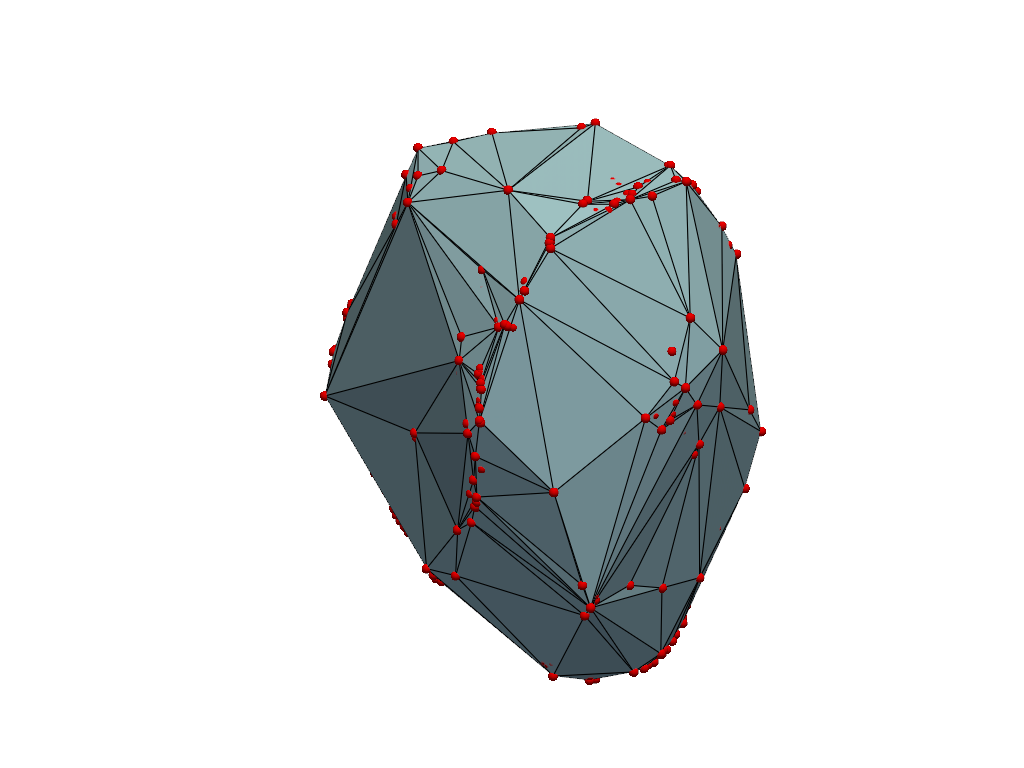

In [154]:
cloud = pv.PolyData(puntos_finales)
##--- 3. GENERAR LA MALLA (Meshing) ---
mesh = cloud.delaunay_3d(alpha=0).extract_surface()

#--- 4. TEXTURIZADO Y MAPEO UV ---
mesh.texture_map_to_sphere(inplace=True)
mesh.texture_map_to_plane(inplace=True) 
tex = pv.examples.download_masonry_texture()

#--- 5. VISUALIZACIÓN ---
plotter = pv.Plotter()
plotter.add_mesh(mesh, cmap="viridis", show_edges=True) # show_edges ayuda a ver la geometría creada
plotter.add_points(cloud, color="red", point_size=10, render_points_as_spheres=True) # Ver puntos originales
plotter.show()